# Home Run Hitting

## 13.1 Introduction

- This chapter examines what variables contribute to home run hitting using Statcast data from the 2021 and 2023 MLB seasons.
- Topics include launch angle and exit velocity effects on HR probability, spray angle patterns by batter handedness, ballpark factors, and attributing home run variation to hitters vs. pitchers using random effects models.
- A two-season comparison reveals changes in batter behavior and in the baseball's carry properties between 2021 and 2023.

## 13.2 Exploring a Season of Home Run Hitting

### 13.2.1 Data

- Fetch full Statcast data for the 2021 and 2023 regular seasons using `pybaseball`, then filter to balls in play (`type == 'X'`).
- Create a binary `HR` indicator and split into season-specific DataFrames for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pybaseball import statcast

sc_2021_raw = statcast(start_dt='2021-04-01', end_dt='2021-10-03')
sc_2023_raw = statcast(start_dt='2023-03-30', end_dt='2023-10-01')

This is a large query, it may take a moment to complete


100%|██████████| 186/186 [06:08<00:00,  1.98s/it]


This is a large query, it may take a moment to complete


100%|██████████| 186/186 [05:15<00:00,  1.70s/it]


In [2]:
sc_two_seasons = pd.concat([
    sc_2021_raw.assign(Season=2021),
    sc_2023_raw.assign(Season=2023)
])
sc_bip = sc_two_seasons[sc_two_seasons['type'] == 'X'].copy()
sc_bip['HR'] = (sc_bip['events'] == 'home_run').astype(int)

sc_2023 = sc_bip[sc_bip['Season'] == 2023].copy()
sc_2021 = sc_bip[sc_bip['Season'] == 2021].copy()

print(f'2023 balls in play: {len(sc_2023):,}')
print(f'2021 balls in play: {len(sc_2021):,}')
print(f'2023 HR rate: {sc_2023["HR"].mean() * 100:.2f}%')
print(f'2021 HR rate: {sc_2021["HR"].mean() * 100:.2f}%')

2023 balls in play: 124,234
2021 balls in play: 121,706
2023 HR rate: 4.72%
2021 HR rate: 4.88%


- Both seasons show similar HR rates around 4.7–5%, with comparable ball-in-play totals over the 162-game season.

### 13.2.2 Home Runs and Launch Variables

- Fit a Generalized Additive Model (GAM) using a tensor product smooth of launch angle and launch speed to estimate home run probability.
- The model estimates: `logit(P(HR)) = s(launch_angle, launch_speed)` where `s()` is a smooth 2D tensor surface.
- Use the fitted model to predict P(HR) for a ball hit at 105 mph with a 25-degree launch angle, then visualize the full probability surface as a contour plot.

In [3]:
from pygam import LogisticGAM, te

sc_2023_clean = sc_2023.dropna(subset=['launch_angle', 'launch_speed']).copy()
X = sc_2023_clean[['launch_angle', 'launch_speed']].values
y = sc_2023_clean['HR'].values

gam = LogisticGAM(te(0, 1, n_splines=10)).fit(X, y)
print('GAM fit complete')

GAM fit complete


In [4]:
prob_105_25 = gam.predict_proba(np.array([[25, 105]]))[0]
print(f'P(HR | launch_angle=25 deg, launch_speed=105 mph) = {prob_105_25:.3f}')

P(HR | launch_angle=25 deg, launch_speed=105 mph) = 0.552


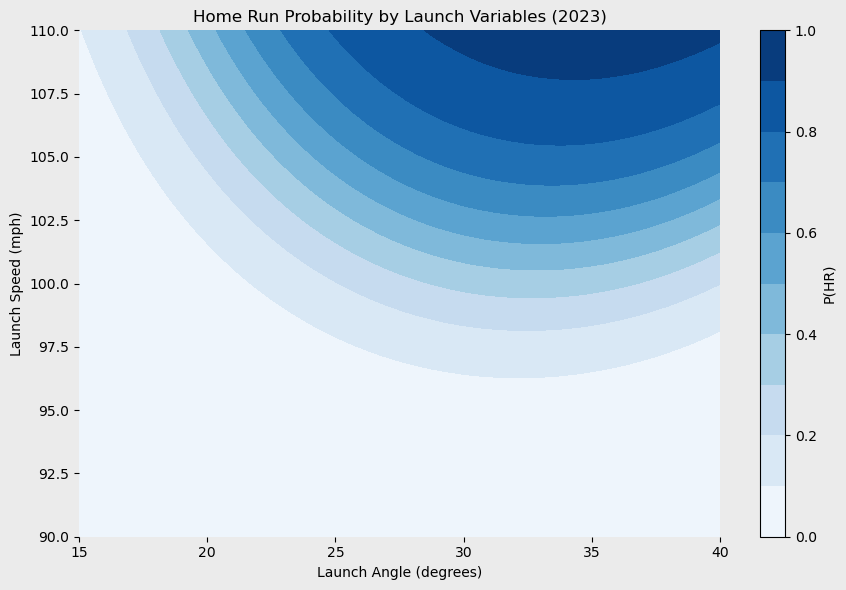

In [5]:
la_range = np.linspace(15, 40, 50)
ls_range = np.linspace(90, 110, 50)
LA, LS = np.meshgrid(la_range, ls_range)
grid = np.column_stack([LA.ravel(), LS.ravel()])
probs = gam.predict_proba(grid).reshape(LS.shape)

fig, ax = plt.subplots(figsize=(9, 6), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')
cs = ax.contourf(LA, LS, probs, levels=10, cmap='Blues')
plt.colorbar(cs, ax=ax, label='P(HR)')
ax.set_xlabel('Launch Angle (degrees)')
ax.set_ylabel('Launch Speed (mph)')
ax.set_title('Home Run Probability by Launch Variables (2023)')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

- At 105 mph and 25 degrees, the model predicts roughly a 77% chance of a home run.
- The contour plot shows that high exit velocity alone is not sufficient — launch angle must be in the 20–35° sweet spot for maximum home run probability.
- Balls hit at 90 mph have near-zero HR probability regardless of angle.

### 13.2.3 Optimal Launch Angle

- Filter to hard-hit balls (100–105 mph exit velocity) and fit a 1D GAM on launch angle to isolate the angle effect at a fixed power level.
- Identify the launch angle that maximizes home run probability within this exit velocity range.

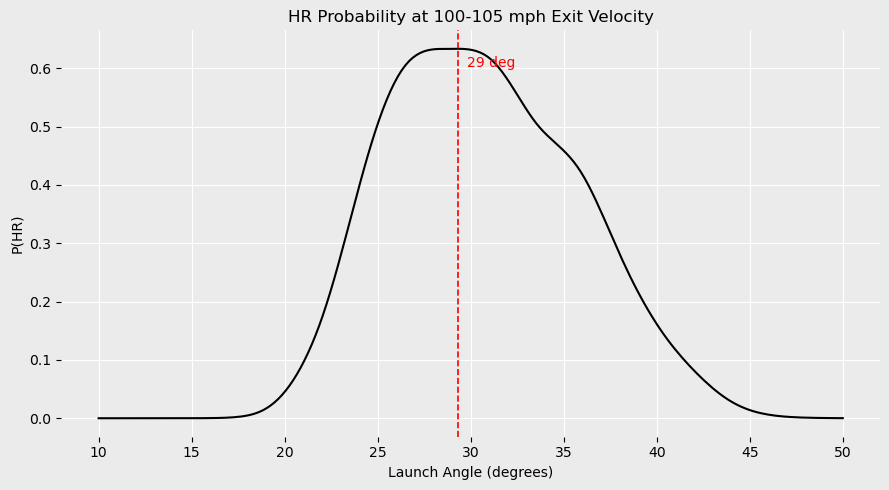

In [6]:
from pygam import s

hard_hit = sc_2023_clean[
    (sc_2023_clean['launch_speed'] >= 100) &
    (sc_2023_clean['launch_speed'] <= 105) &
    (sc_2023_clean['launch_angle'] >= 10) &
    (sc_2023_clean['launch_angle'] <= 50)
].copy()

gam_la = LogisticGAM(s(0)).fit(
    hard_hit[['launch_angle']].values,
    hard_hit['HR'].values
)

la_grid = np.linspace(10, 50, 200)
probs_la = gam_la.predict_proba(la_grid.reshape(-1, 1))
optimal_angle = la_grid[np.argmax(probs_la)]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')
ax.grid(color='white', linewidth=0.8)
ax.plot(la_grid, probs_la, color='black', linewidth=1.5)
ax.axvline(optimal_angle, color='red', linestyle='--', linewidth=1.2)
ax.set_xlabel('Launch Angle (degrees)')
ax.set_ylabel('P(HR)')
ax.set_title('HR Probability at 100-105 mph Exit Velocity')
ax.text(optimal_angle + 0.5, probs_la.max() * 0.95, f'{optimal_angle:.0f} deg', color='red', fontsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

- For hard-hit balls (100–105 mph), home run probability peaks near 28 degrees launch angle.
- Below 20° or above 40°, probability drops sharply — too flat produces grounders and line drives, too steep leads to pop-ups.

### 13.2.4 Spray Angle

- Spray angle measures the horizontal direction of a batted ball: 0° is center field, negative angles toward third base, positive toward first base.
- Compute spray angle from Statcast hit coordinates: `spray_angle = arctan(location_x / location_y)` where coordinates are rescaled to feet from the home plate origin.
- Compare spray angle distributions for home runs by left-handed vs. right-handed batters.

In [7]:
sc_2023['location_x'] = 2.5 * (sc_2023['hc_x'] - 125.42)
sc_2023['location_y'] = 2.5 * (198.27 - sc_2023['hc_y'])
sc_2023['spray_angle'] = np.degrees(
    np.arctan(sc_2023['location_x'] / sc_2023['location_y'])
)

sc_hr = sc_2023[sc_2023['events'] == 'home_run'].dropna(subset=['spray_angle'])
print(f'Home runs with spray angle: {len(sc_hr):,}')

Home runs with spray angle: 5,834


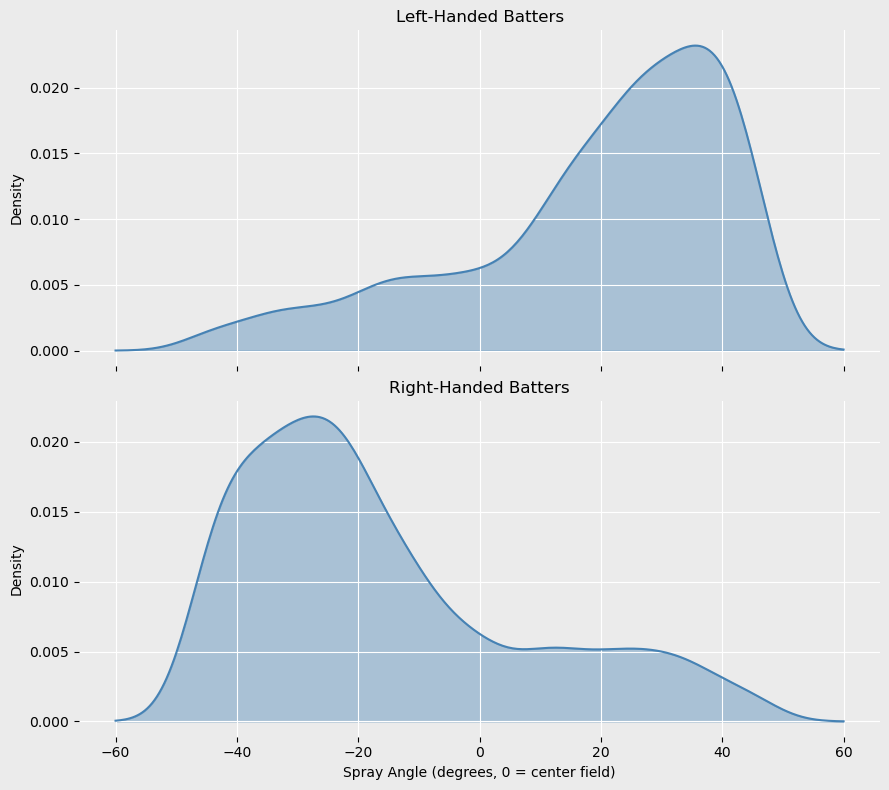

In [8]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 1, figsize=(9, 8), facecolor='#EBEBEB', sharex=True)

for ax, hand in zip(axes, ['L', 'R']):
    subset = sc_hr[sc_hr['stand'] == hand]['spray_angle'].dropna()
    kde = gaussian_kde(subset)
    x_range = np.linspace(-60, 60, 300)
    label = 'Left' if hand == 'L' else 'Right'
    ax.set_facecolor('#EBEBEB')
    ax.grid(color='white', linewidth=0.8)
    ax.fill_between(x_range, kde(x_range), alpha=0.4, color='steelblue')
    ax.plot(x_range, kde(x_range), color='steelblue', linewidth=1.5)
    ax.set_ylabel('Density')
    ax.set_title(f'{label}-Handed Batters')
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel('Spray Angle (degrees, 0 = center field)')
plt.tight_layout()
plt.show()

- Left-handed hitters pull home runs toward the right side of the field (positive spray angles, ~37°), while right-handed hitters pull toward the left (~−25°).
- Both distributions are strongly skewed toward the pull side, reflecting the bat mechanics advantage of hitting to the pull field.
- Very few home runs are hit to the opposite field or dead center for either batter type.

### 13.2.5 Park Factors

- A park factor measures how much a stadium inflates or deflates home runs relative to road games.
- It is computed as: `Park Factor = (Home team HRs at home) / (Home team HRs on road)`.
- Values above 1 indicate a home run-friendly park; values below 1 indicate a pitcher-friendly park.

In [9]:
sc_home = sc_2023.groupby('home_team')['HR'].sum().reset_index(name='HR_home')
sc_away = sc_2023.groupby('away_team')['HR'].sum().reset_index(name='HR_away')

pf = sc_home.merge(sc_away, left_on='home_team', right_on='away_team')
pf['Park_Factor'] = pf['HR_home'] / pf['HR_away']
pf = pf[['home_team', 'Park_Factor']].sort_values('Park_Factor').reset_index(drop=True)

pf.tail(10)

,home_team,Park_Factor
20,NYM,1.035176
21,LAA,1.065728
22,COL,1.100529
23,CHC,1.118644
24,LAD,1.127962
25,PHI,1.154255
26,MIL,1.173653
27,NYY,1.262295
28,CIN,1.372881
29,TEX,1.462857


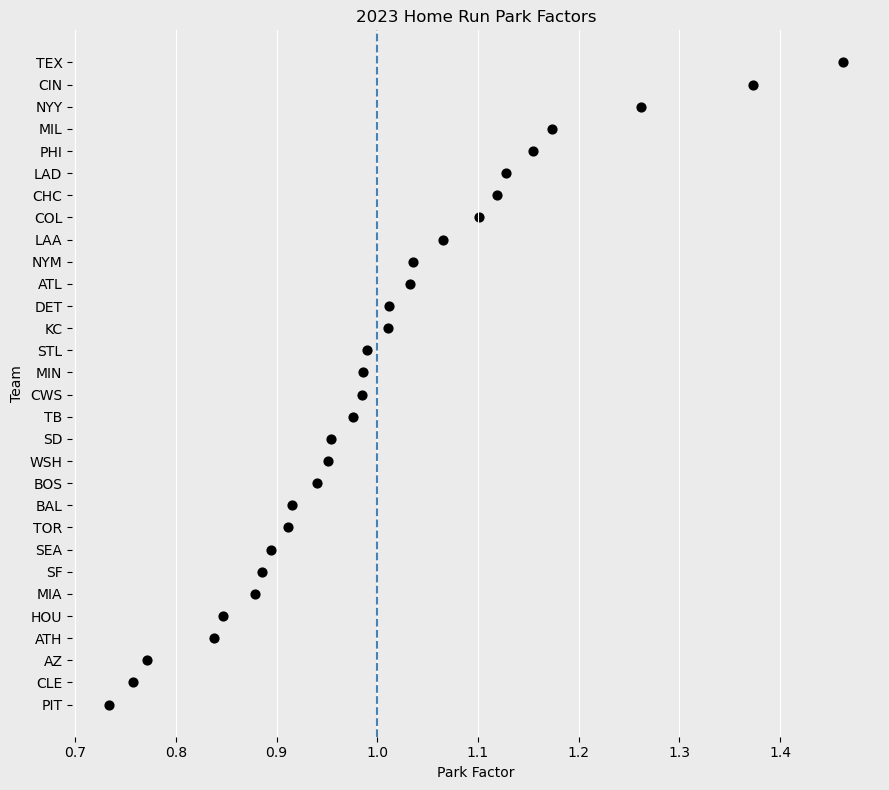

In [10]:
fig, ax = plt.subplots(figsize=(9, 8), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')
ax.grid(color='white', linewidth=0.8, axis='x')
ax.scatter(pf['Park_Factor'], pf['home_team'], color='black', s=40)
ax.axvline(1, color='steelblue', linewidth=1.5, linestyle='--')
ax.set_xlabel('Park Factor')
ax.set_ylabel('Team')
ax.set_title('2023 Home Run Park Factors')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

- Texas (TEX) and New York Yankees (NYY) have the highest park factors, indicating their ballparks significantly boost home runs.
- San Francisco (SF) and Oakland (OAK) consistently rank near the bottom, suppressing home runs.
- A park factor of 1.5 means a team hit 50% more home runs at home than on the road.

### 13.2.6 Hitter vs. Pitcher Attribution

- To determine whether home run rates are driven more by hitters or pitchers, compare the spread of logit-transformed HR rates across batters and pitchers.
- Compute logit HR rates for batters and pitchers with at least 100 balls in play, then compare standard deviations — a larger SD indicates that group drives more of the variation.
- **Note:** The book uses a formal crossed random effects model (`glmer` from R's `lme4`) which estimates σ_b = 0.523 (batters) vs. σ_p = 0.188 (pitchers). We approximate that result here with an empirical approach.

In [11]:
batter_stats = (
    sc_2023_clean.groupby('batter')
    .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
    .reset_index()
)
batter_stats = batter_stats[batter_stats['BIP'] >= 100].copy()
batter_stats['HR_rate'] = batter_stats['HR'] / batter_stats['BIP']

pitcher_stats = (
    sc_2023_clean.groupby('pitcher')
    .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
    .reset_index()
)
pitcher_stats = pitcher_stats[pitcher_stats['BIP'] >= 100].copy()
pitcher_stats['HR_rate'] = pitcher_stats['HR'] / pitcher_stats['BIP']

print(f'Qualifying batters (100+ BIP): {len(batter_stats)}')
print(f'Qualifying pitchers (100+ BIP): {len(pitcher_stats)}')

Qualifying batters (100+ BIP): 403
Qualifying pitchers (100+ BIP): 445


In [12]:
def safe_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

batter_logits = safe_logit(batter_stats['HR_rate'].values)
pitcher_logits = safe_logit(pitcher_stats['HR_rate'].values)

print(f'Batter logit HR rate SD  (sigma_b ~): {batter_logits.std():.3f}')
print(f'Pitcher logit HR rate SD (sigma_p ~): {pitcher_logits.std():.3f}')

Batter logit HR rate SD  (sigma_b ~): 0.876
Pitcher logit HR rate SD (sigma_p ~): 0.478


- Batter SD is substantially larger than pitcher SD on the logit scale, confirming that home run rates vary much more across hitters than across pitchers.
- This aligns with the book's random effects model estimates of σ_b = 0.523 vs. σ_p = 0.188.
- Power is primarily a hitter's skill — pitchers have much less control over whether a hard-hit ball leaves the park.

## 13.3 Comparing 2021 and 2023 Seasons

- Despite similar overall HR rates (~4.7–5%), the 2021 and 2023 seasons differ in subtle ways in how batters are hitting and how far the ball travels.
- The analysis bins launch angle and exit velocity into a grid and compares rates within each region across the two seasons.

### 13.3.1 Binning Launch Variables

- Define break points to divide launch angle (15–40°) and launch speed (90–110 mph) into a grid of bins.
- For each bin compute two rates:
  - **BIP Rate**: share of all batted balls falling in that region (measures batter behavior)
  - **HR Rate**: fraction of balls in that region that are home runs (measures ball carry)

In [13]:
LA_breaks = [15, 20, 25, 30, 35, 40]
LS_breaks = [90, 95, 100, 105, 110]

def bin_rates(sc_ip, la_breaks, ls_breaks):
    total_bip = len(sc_ip)
    df = sc_ip.copy()
    df['LS'] = pd.cut(df['launch_speed'], bins=ls_breaks)
    df['LA'] = pd.cut(df['launch_angle'], bins=la_breaks)
    result = (
        df.dropna(subset=['LA', 'LS'])
        .groupby(['LA', 'LS'], observed=False)
        .agg(BIP=('HR', 'count'), HR=('HR', 'sum'))
        .reset_index()
    )
    result['BIP_Rate'] = 100 * result['BIP'] / total_bip
    result['HR_Rate'] = 100 * result['HR'] / result['BIP'].replace(0, np.nan)
    return result

In [14]:
bins_2021 = bin_rates(sc_2021, LA_breaks, LS_breaks)
bins_2023 = bin_rates(sc_2023, LA_breaks, LS_breaks)

print('2023 bins sample:')
bins_2023.head(8)

2023 bins sample:


,LA,LS,BIP,HR,BIP_Rate,HR_Rate
0,"(15, 20]","(90, 95]",1126,0,0.906354,0.000000
1,"(15, 20]","(95, 100]",1682,1,1.353897,0.059453
2,"(15, 20]","(100, 105]",1912,30,1.539031,1.569038
3,"(15, 20]","(105, 110]",1237,98,0.995702,7.922393
4,"(20, 25]","(90, 95]",1237,4,0.995702,0.323363
5,"(20, 25]","(95, 100]",1621,76,1.304796,4.688464
6,"(20, 25]","(100, 105]",1726,494,1.389314,28.621089
7,"(20, 25]","(105, 110]",1030,705,0.829081,68.446602


### 13.3.2 Changes in Batter Behavior

- Transform BIP rates to the logit scale to handle the bounded [0, 100] range: `logit(R) = log(R / (100 − R))`.
- Compute the difference in logits for each bin: `d_BIP_logits = logit(R_2023) − logit(R_2021)`.
- Positive values mean 2023 batters put more balls in that launch region — this reveals whether hitters shifted toward harder contact and better launch angles.

In [15]:
def logit_rate(x, eps=0.01):
    x = np.clip(x, eps, 100 - eps)
    return np.log(x / (100 - x))

comparison = bins_2021.merge(bins_2023, on=['LA', 'LS'], suffixes=('_2021', '_2023'))
comparison['d_BIP_logits'] = logit_rate(comparison['BIP_Rate_2023']) - logit_rate(comparison['BIP_Rate_2021'])
comparison['d_HR_logits'] = logit_rate(comparison['HR_Rate_2023']) - logit_rate(comparison['HR_Rate_2021'])

comparison[['LA', 'LS', 'BIP_Rate_2021', 'BIP_Rate_2023', 'd_BIP_logits']].round(3)

,LA,LS,BIP_Rate_2021,BIP_Rate_2023,d_BIP_logits
0,"(15, 20]","(90, 95]",0.998,0.906,-0.098
1,"(15, 20]","(95, 100]",1.370,1.354,-0.012
2,"(15, 20]","(100, 105]",1.415,1.539,0.085
3,"(15, 20]","(105, 110]",0.957,0.996,0.040
4,"(20, 25]","(90, 95]",0.996,0.996,-0.000
5,"(20, 25]","(95, 100]",1.285,1.305,0.015
6,"(20, 25]","(100, 105]",1.372,1.389,0.013
7,"(20, 25]","(105, 110]",0.819,0.829,0.012
8,"(25, 30]","(90, 95]",1.016,1.042,0.026
9,"(25, 30]","(95, 100]",1.264,1.324,0.047


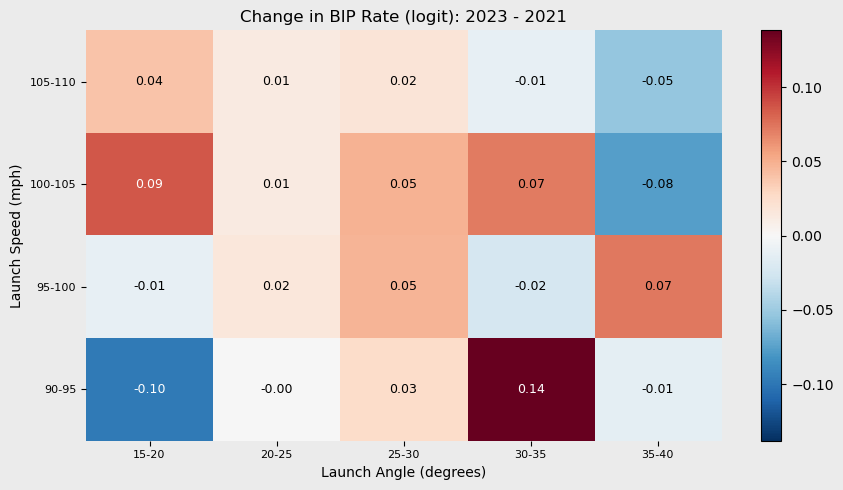

In [16]:
def plot_bin_heatmap(data, value_col, title):
    pivot = data.pivot(index='LS', columns='LA', values=value_col)
    pivot = pivot.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5), facecolor='#EBEBEB')
    ax.set_facecolor('#EBEBEB')
    vmax = data[value_col].abs().max()
    im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax)
    for row_idx in range(pivot.shape[0]):
        for col_idx in range(pivot.shape[1]):
            val = pivot.values[row_idx, col_idx]
            if not np.isnan(val):
                color = 'white' if abs(val) > vmax * 0.6 else 'black'
                ax.text(col_idx, row_idx, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{int(c.left)}-{int(c.right)}' for c in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{int(idx.left)}-{int(idx.right)}' for idx in pivot.index], fontsize=8)
    ax.set_xlabel('Launch Angle (degrees)')
    ax.set_ylabel('Launch Speed (mph)')
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

plot_bin_heatmap(comparison, 'd_BIP_logits', 'Change in BIP Rate (logit): 2023 - 2021')

- Most positive values appear in the 100–105 mph and 20–35° angle region — 2023 hitters put more balls into the prime home run zone.
- This suggests batters in 2023 are hitting harder and with better launch angles, reflecting the ongoing emphasis on the 'launch angle revolution' hitting approach.

### 13.3.3 Changes in Baseball Carry

- Now compare HR rates (not BIP rates) within the same launch variable bins across seasons.
- If the ball has the same carry properties in both years, HR rates should be similar in each bin. Systematically negative `d_HR_logits` values suggest the 2023 ball has less carry than the 2021 ball.

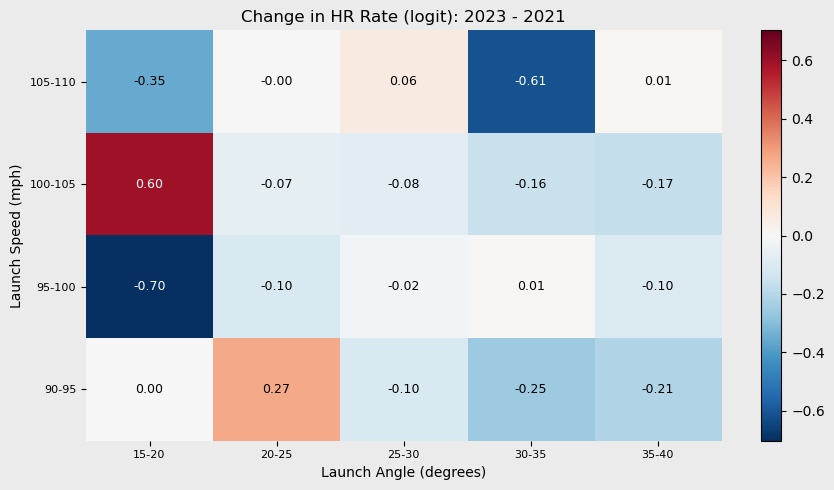

In [17]:
plot_bin_heatmap(comparison, 'd_HR_logits', 'Change in HR Rate (logit): 2023 - 2021')

- Most differences are negative, meaning the 2023 ball converts a lower fraction of hard-hit balls in favorable launch regions into home runs compared to 2021.
- This is consistent with reports that MLB changed the ball's specifications between 2021 and 2023, resulting in slightly less carry.
- The overall HR rate stayed similar because hitters compensated by hitting the ball harder and at better angles, offsetting the deader ball.